In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter


df = pd.read_csv('cleaned_housesales_data.csv')

In [32]:
features = {
    "Waterfront": "waterfront",
    "View": "view",
    "Renovated": "is_renovated",
    "Basement": "has_basement"
}

rows = []

for name, col in features.items():
    with_feature = df.loc[df[col] > 0, "price"].median() if col == "view" else (df.loc[df[col] == 1, "price"].median() if col == "waterfront" else df.loc[df[col] == True, "price"].median())
    without_feature = df.loc[df[col] == 0, "price"].median()
    premium = (with_feature - without_feature) / without_feature * 100

    rows.append([name, without_feature, with_feature, premium])

feature_price = pd.DataFrame(
    rows,
    columns=["feature", "without", "with", "premium"]
)

def money_fmt(x, pos=None):
    if x >= 1_000_000:
        return f"${x / 1_000_000:.1f}M"
    elif x >= 1_000:
        return f"${x / 1_000:.0f}K"
    return f"${x:,.0f}"

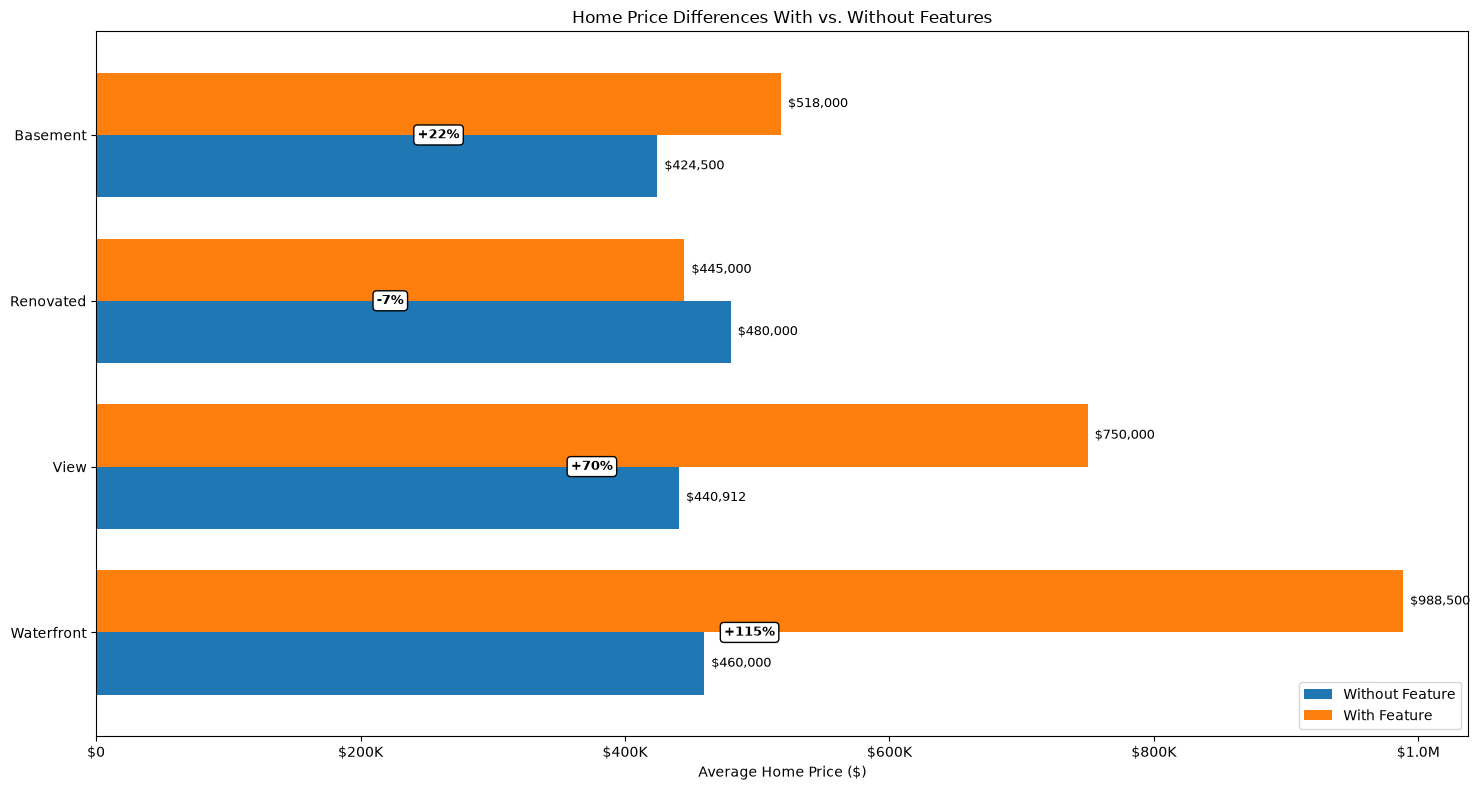

In [31]:
plot_df = feature_price.set_index("feature")[["without", "with"]]

ax = plot_df.plot(
    kind="barh",
    figsize=(15, 8),
    width=0.75
)

ax.set_title("Home Price Differences With vs. Without Features")
ax.set_xlabel("Average Home Price ($)")
ax.set_ylabel("")

ax.xaxis.set_major_formatter(
    FuncFormatter(money_fmt)
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"${v:,.0f}" for v in container.datavalues],
        padding=5,
        fontsize=9
    )

# Premium label — "With" barlariga
for i, premium in enumerate(feature_price["premium"]):
    value = feature_price.loc[i, "with"]

    ax.text(
        value / 2,
        i,
        f"{premium:+.0f}%",
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="black",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="black",
            linewidth=1
        )
    )

ax.legend(
    ["Without Feature", "With Feature"],
    loc="lower right"
)

plt.tight_layout()
plt.show()

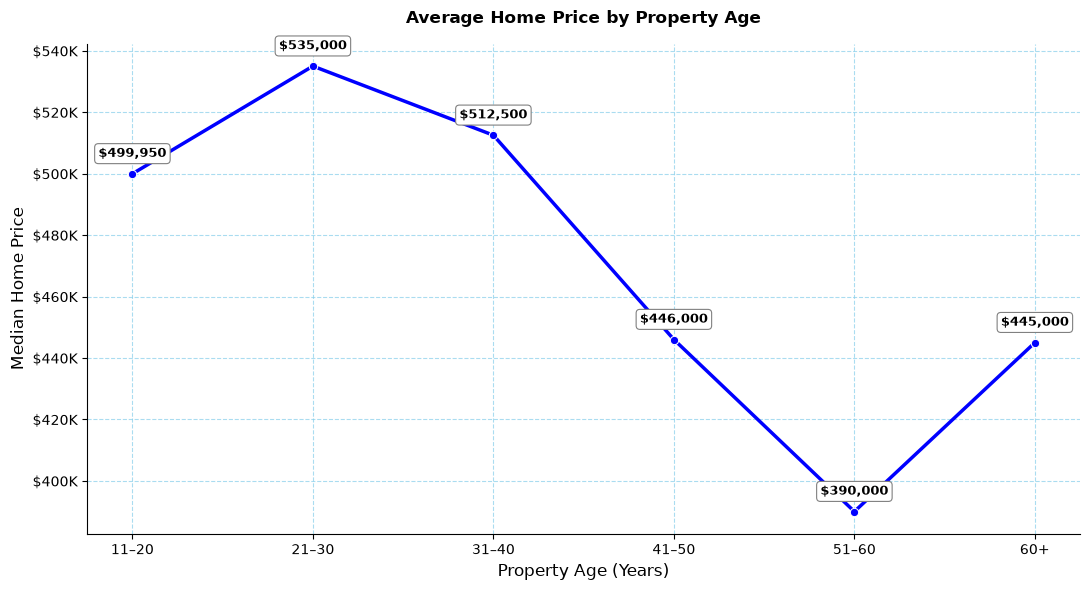

In [46]:
age_bins = [0, 10, 20, 30, 40, 50, 60, float('inf')]
age_labels = ['0–10', '11–20', '21–30', '31–40', '41–50', '51–60', '60+']

df['age_group'] = pd.cut(
    df['house_age'], bins=age_bins, labels=age_labels, include_lowest=True
)

age_price = (
    df.groupby('age_group', observed=True)['price'].median().reset_index()
)


def money_fmt(x, pos=None):
  if x >= 1_000_000:
    return f'${x / 1_000_000:.1f}M'
  elif x >= 1_000:
    return f'${x / 1_000:.0f}K'
  return f'${x:,.0f}'


plt.figure(figsize=(11, 6))

ax = sns.lineplot(
    data=age_price, x='age_group', y='price', marker='o', linewidth=2.5, color='b'
)

# Gridline sozlamalari (dashed va havorang)
ax.grid(True, linestyle='--', color='skyblue', alpha=0.7)

ax.set_title(
    'Average Home Price by Property Age', fontsize=12, fontweight='bold', pad=15
)
ax.set_xlabel('Property Age (Years)', fontsize=12)
ax.set_ylabel('Median Home Price', fontsize=12)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(money_fmt))

# Nuqtalar ustidagi data labellar
for i, row in age_price.iterrows():
  x_val = row['age_group']
  y_val = row['price']

  ax.annotate(
      f'${y_val:,.0f}',
      (x_val, y_val),
      xytext=(0, 10),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=9,
      fontweight='bold',
      bbox=dict(
          boxstyle='round,pad=0.3',
          facecolor='white',
          edgecolor='gray',
          linewidth=0.8,
      ),
  )

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()